In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Problem Statement

The objective of this project is to analyze Google Play Store application data to uncover insights about app categories, ratings, installs, pricing, and popularity trends. 
The analysis aims to help understand app market dynamics and user preferences.

In [4]:
import pandas as pd

apps = pd.read_csv("apps.csv")

In [8]:
apps.head()
apps.info()
apps.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


(9659, 14)

In [10]:
apps.drop("Unnamed: 0", axis=1, inplace=True)

In [14]:
apps.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [22]:
apps = apps.dropna(subset=["Rating"])

In [24]:
apps["Installs"] = apps["Installs"].str.replace(",", "")
apps["Installs"] = apps["Installs"].str.replace("+", "", regex=False)
apps["Installs"] = apps["Installs"].astype(int)

In [26]:
apps["Price"] = apps["Price"].str.replace("$", "", regex=False)
apps["Price"] = apps["Price"].astype(float)

In [28]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   object 
 1   Category        8196 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            7027 non-null   float64
 5   Installs        8196 non-null   int32  
 6   Type            8196 non-null   object 
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   object 
 9   Genres          8196 non-null   object 
 10  Last Updated    8196 non-null   object 
 11  Current Ver     8192 non-null   object 
 12  Android Ver     8194 non-null   object 
dtypes: float64(3), int32(1), int64(1), object(8)
memory usage: 864.4+ KB


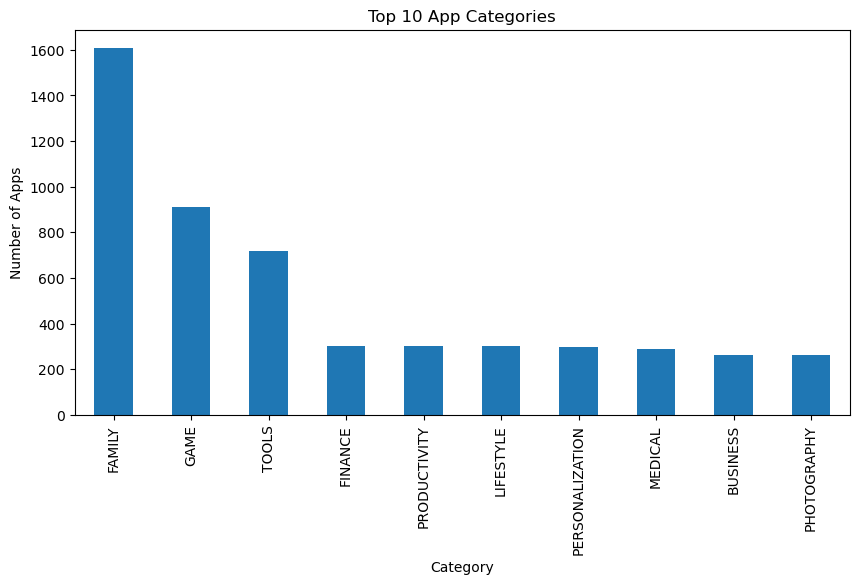

In [30]:
plt.figure(figsize=(10,5))

apps["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 App Categories")
plt.ylabel("Number of Apps")

plt.savefig("top_categories.png")

plt.show()

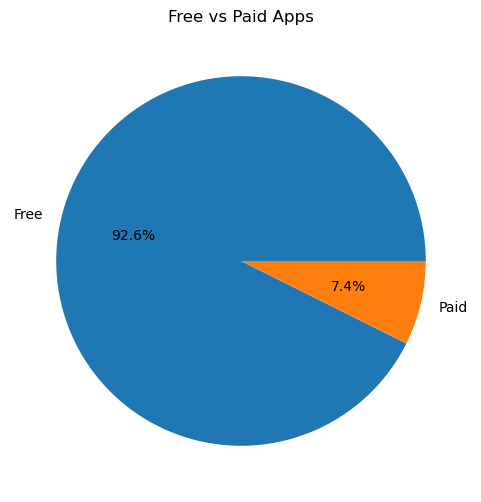

In [32]:
plt.figure(figsize=(6,6))

apps["Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Free vs Paid Apps")

plt.savefig("free_vs_paid.png")

plt.show()

In [34]:
category_rating = apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)

category_rating.head(10)

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
PARENTING              4.300000
BEAUTY                 4.278571
GAME                   4.247368
SOCIAL                 4.247291
WEATHER                4.243056
Name: Rating, dtype: float64

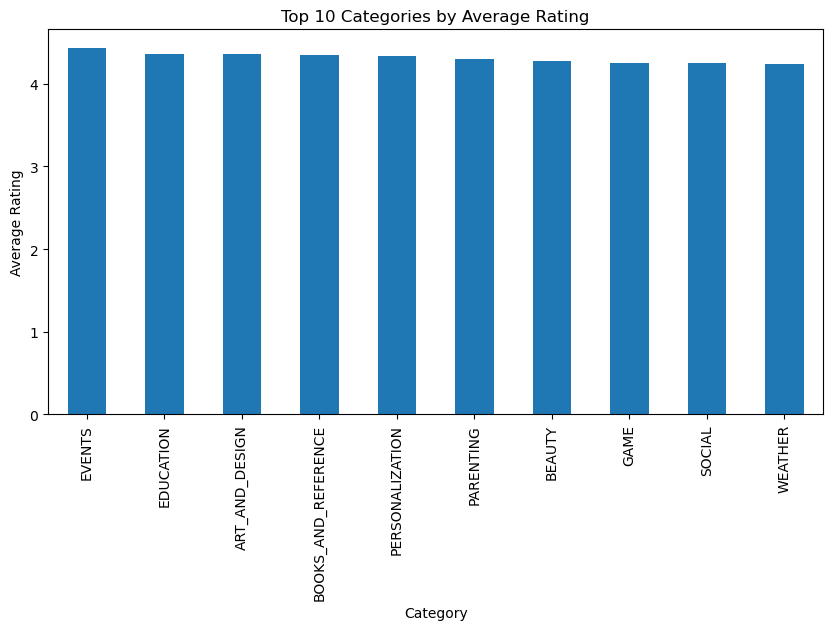

In [36]:
plt.figure(figsize=(10,5))

category_rating.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Rating")
plt.ylabel("Average Rating")

plt.savefig("top_rated_categories.png")

plt.show()

In [38]:
category_installs = apps.groupby("Category")["Installs"].sum().sort_values(ascending=False)

category_installs.head(10)

Category
GAME                  13878762717
COMMUNICATION         11038241530
TOOLS                  7999724500
PRODUCTIVITY           5793070180
SOCIAL                 5487841475
PHOTOGRAPHY            4649143130
FAMILY                 4427479590
VIDEO_PLAYERS          3926797200
TRAVEL_AND_LOCAL       2894859300
NEWS_AND_MAGAZINES     2369110650
Name: Installs, dtype: int64

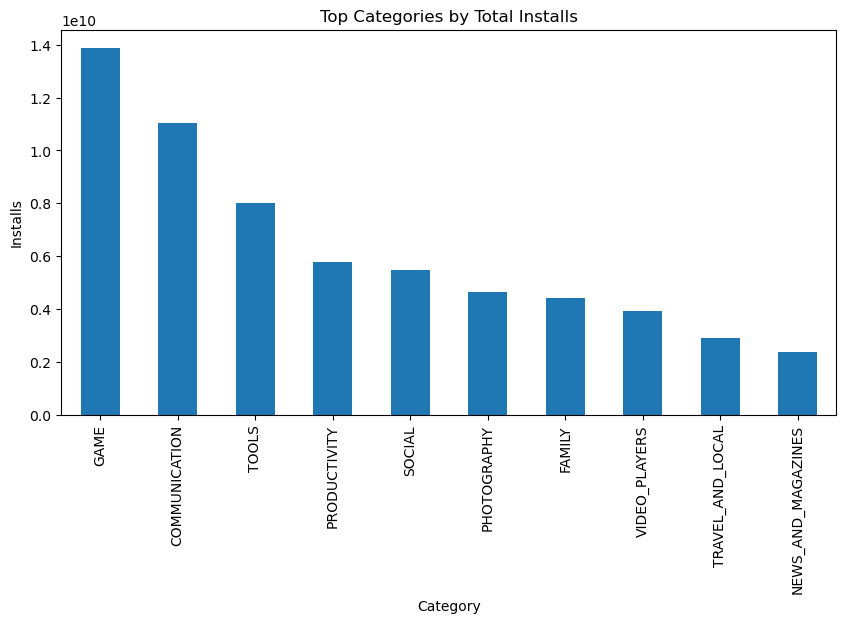

In [40]:
plt.figure(figsize=(10,5))

category_installs.head(10).plot(kind="bar")

plt.title("Top Categories by Total Installs")
plt.ylabel("Installs")

plt.savefig("top_installed_categories.png")

plt.show()

In [42]:
top_apps = apps.sort_values(
    by="Installs",
    ascending=False
)[["App","Category","Installs"]]

top_apps.head(10)

,App,Category,Installs
2977,Google News,NEWS_AND_MAGAZINES,1000000000
2507,Google,TOOLS,1000000000
2002,Facebook,SOCIAL,1000000000
2003,Instagram,SOCIAL,1000000000
299,Messenger – Text and Video Chat for Free,COMMUNICATION,1000000000
300,WhatsApp Messenger,COMMUNICATION,1000000000
302,Google Chrome: Fast & Secure,COMMUNICATION,1000000000
304,Gmail,COMMUNICATION,1000000000
2012,Google+,SOCIAL,1000000000
305,Hangouts,COMMUNICATION,1000000000


In [44]:
apps.groupby("Type")["Rating"].mean()

Type
Free    4.166372
Paid    4.259603
Name: Rating, dtype: float64

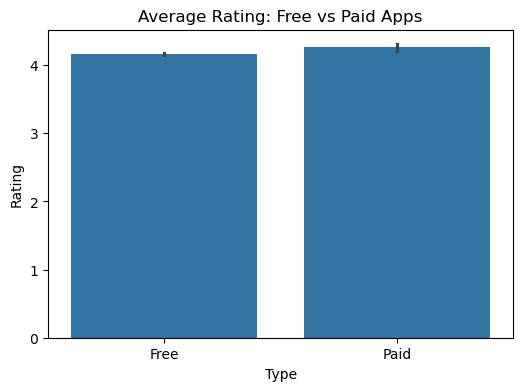

In [46]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Type",
    y="Rating",
    data=apps
)

plt.title("Average Rating: Free vs Paid Apps")

plt.savefig("free_paid_rating.png")

plt.show()

In [48]:
apps["Genres"].value_counts().head(10)

Genres
Tools              717
Entertainment      471
Education          429
Finance            302
Productivity       301
Lifestyle          300
Personalization    298
Action             292
Medical            290
Sports             266
Name: count, dtype: int64

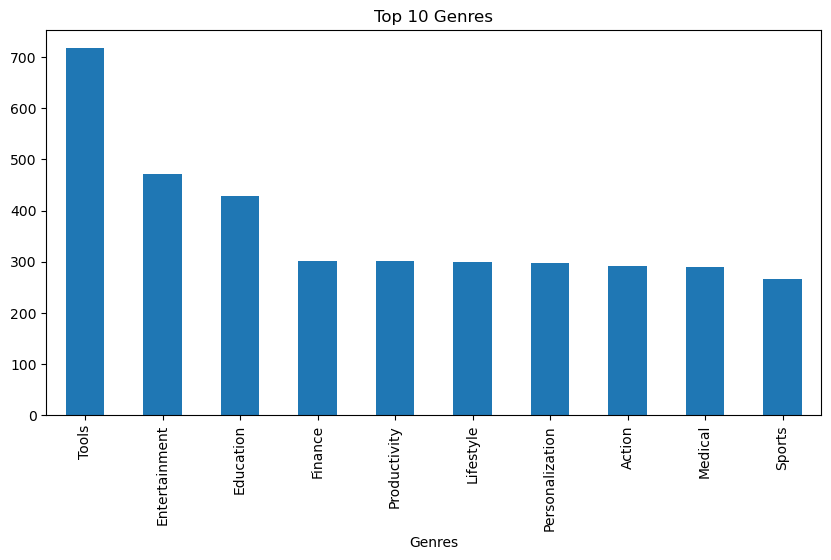

In [50]:
plt.figure(figsize=(10,5))

apps["Genres"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Genres")

plt.savefig("top_genres.png")

plt.show()

# Key Insights

- The Play Store is dominated by a few major categories.
- Free apps significantly outnumber paid apps.
- Certain categories achieve consistently higher ratings.
- A small number of apps account for the majority of installs.
- User preferences vary strongly across genres and categories.

In [52]:
reviews = pd.read_csv("user_reviews.csv")

In [56]:
reviews.head()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [58]:
reviews["Sentiment"].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

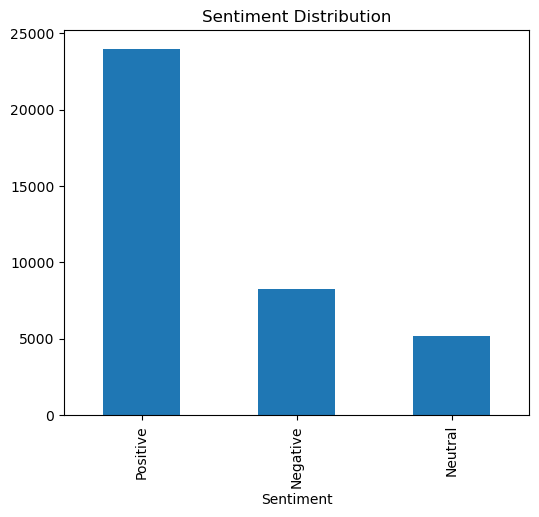

In [60]:
plt.figure(figsize=(6,5))

reviews["Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")

plt.savefig("sentiment_distribution.png")

plt.show()

In [62]:
sentiment_app = reviews.groupby("App")["Sentiment_Polarity"].mean()

sentiment_app.sort_values(
    ascending=False
).head(10)

App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.687500
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64

In [64]:
top_positive = reviews.groupby("App")[
    "Sentiment_Polarity"
].mean().sort_values(
    ascending=False
)

top_positive.head(10)

App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.687500
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64

# Recommendations

- Focus development efforts on high-growth categories.
- Improve user experience in poorly rated app segments.
- Use positive user feedback to guide feature development.
- Explore monetization opportunities in high-install categories.

# Conclusion

The analysis of Google Play Store data revealed important trends in app categories, ratings, installs, pricing, and user sentiment. 
These insights can help developers and businesses make data-driven decisions regarding app development, marketing, and monetization.